In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

In [3]:
# Чтение
img = Image.open(r"C:\Users\user\Downloads\icc.jfif")
img_gray = img.convert('L')  # Серый
img_array = np.array(img_gray) 

h, w = img_array.shape
original_shape = img_array.shape
original_flat = img_array.flatten()

## Выводы по блоку А. Загрузка и подготовка данных

- Изображение успешно загружено из файла `icc.jfif` и переведено в чёрно-белое
- После преобразования в оттенки серого получена матрица 

In [6]:
# SVD
U, s, Vt = np.linalg.svd(img_array, full_matrices=False)

# Задаём ранги
list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]
approximations = []

# Восстановление для ранга r
for r in list_of_ranks:
    # Умножение без создания полной диагональной матрицы (работает быстрее)
    approx = (U[:, :r] * s[:r]) @ Vt[:r, :]
    approximations.append(approx)

## Выводы по блоку Б. Применение SVD и восстановление

- Исходная матрица изображения разложена с помощью SVD на три составляющие: $U$, $\Sigma$ (сингулярные числа сохранены в вектор `s`) и $V^T$.
- Для каждого из заданных рангов $r$ выполнено восстановление, где оставлялись только $r$ наибольших сингулярных чисел.
- Установлено, что с ростом $r$ качество восстановления улучшается

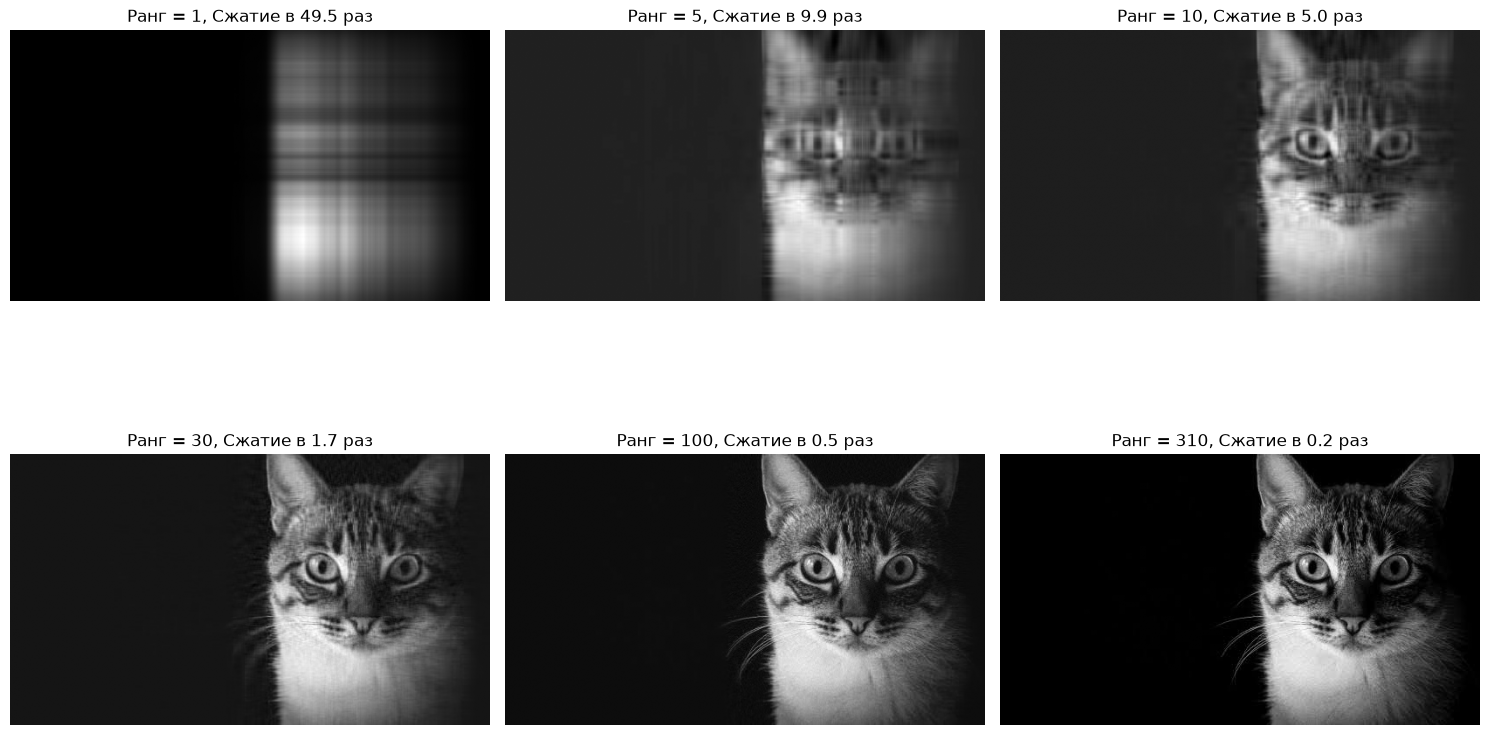

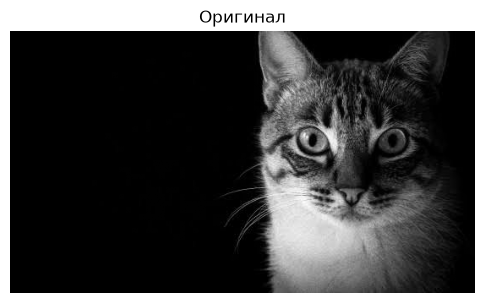

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Исходный размер в байтах
original_bytes = h * w 

for i, r in enumerate(list_of_ranks):
    # Размер сжатого: r * (h + 1 + w) чисел. float32 = 4 байта
    compressed_bytes = r * (h + 1 + w) * 4 
    compression_ratio = original_bytes / compressed_bytes
    
    axes[i].imshow(approximations[i], cmap='gray')
    axes[i].set_title(f"Ранг = {r}, Сжатие в {compression_ratio:.1f} раз")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Оригинал отдельно
plt.figure(figsize=(6,6))
plt.imshow(img_array, cmap='gray')
plt.title("Оригинал")
plt.axis('off')
plt.show()

## Выводы по блоку В. Визуализация результатов

- Наглядно видно, как с ростом ранга улучшается детализация:
  - при r=1-5 – видны контуры,
  - при r=10 – изображение узнаваемо,
  - при r=30 – качество хорошее,
  - при r=100 – почти неотличимо от оригинала,
  - при r=310 – точная копия.

In [9]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
        assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
        assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


## Выводы

- Порог визуальной неразличимости для данного изображения лежит между рангами 30 и 100
- 10‑кратное сжатие достигается при ранге 5
- SVD лучше всего улавливает плавные градиенты и крупные однородные области (светлые/темные пятна). Мелкие детали, шум и резкие контрастные границы (текстуры) требуют высоких рангов, поэтому на них ошибка при низких $r$ максимальна.

RGB

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

In [ ]:
# Чтение
img = Image.open(r"C:\Users\user\Downloads\icc.jfif").convert('RGB') 
# Переводим в float32 для корректных математических операций SVD
img_array = np.array(img, dtype=np.float32)

h, w, c = img_array.shape
original_shape = img_array.shape
original_flat = img_array.flatten()

# Исходный размер: 1 байт на канал (uint8)
original_bytes = h * w * c

In [13]:
list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]
approximations = []

for r in list_of_ranks:
    reconstructed_channels = []
    for channel in range(c):
        # Разложение каждого канала отдельно
        U, s, Vt = np.linalg.svd(img_array[:, :, channel], full_matrices=False)
        # Быстрое восстановление через broadcasting (без создания diag-матрицы)
        approx_channel = (U[:, :r] * s[:r]) @ Vt[:r, :]
        reconstructed_channels.append(approx_channel)
    
    # Собираем каналы обратно в единое изображение (H x W x 3)
    approx_img = np.stack(reconstructed_channels, axis=-1)
    approximations.append(approx_img)

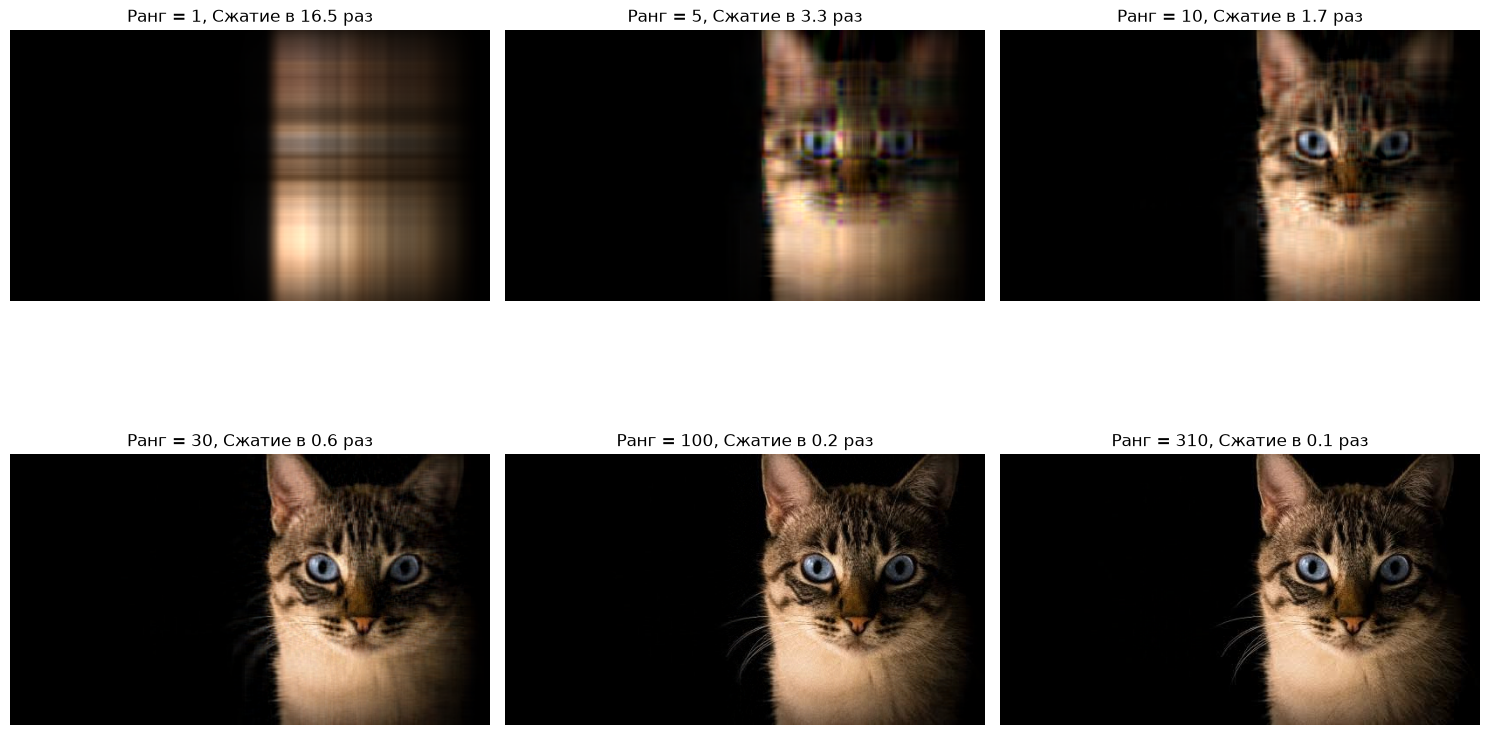

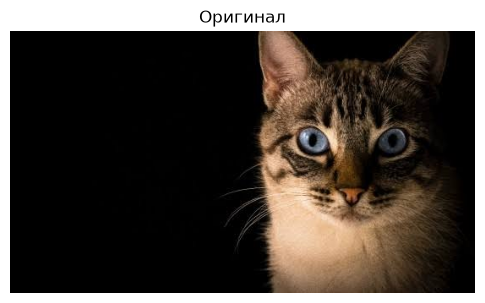

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, r in enumerate(list_of_ranks):
    # Размер сжатого: 3 канала * r * (h + 1 + w) чисел. float32 = 4 байта
    compressed_bytes = c * r * (h + 1 + w) * 4
    compression_ratio = original_bytes / compressed_bytes
    
    # Для корректного отображения ограничиваем диапазон [0, 255] и приводим к uint8
    display_img = np.clip(approximations[i], 0, 255).astype(np.uint8)
    
    axes[i].imshow(display_img)
    axes[i].set_title(f"Ранг = {r}, Сжатие в {compression_ratio:.1f} раз")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Оригинал отдельно
plt.figure(figsize=(6,6))
plt.imshow(img_array.astype(np.uint8))
plt.title("Оригинал")
plt.axis('off')
plt.show()

In [20]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
        assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
        assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!
